In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns
import plotly.figure_factory as ff
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.express as px
import requests

In [7]:
df = pd.read_csv(r"C:\Users\timur\Downloads\CarAnalysis\Dataset\Stacked\used_cars_clean.csv")

# Text EDA(Exploratory Data Analysis)

# UK Used Car Dataset – Description

## Overview

This dataset contains **108,540 used car listings** from the UK automotive market.  
Each row represents a single vehicle listing with technical specifications and pricing information.

The dataset includes both **numerical** and **categorical** features suitable for exploratory data analysis, regression modelling, and business insights generation.

---

## Features Description

| Feature        | Type        | Description |
|---------------|------------|-------------|
| model         | Categorical | Vehicle model name |
| year          | Numerical (int) | Manufacturing year |
| price         | Numerical (float) | Listed vehicle price (£) |
| transmission  | Categorical | Gearbox type (Manual / Automatic / etc.) |
| mileage       | Numerical (int) | Distance travelled (miles) |
| fuelType      | Categorical | Fuel type (Petrol / Diesel / Hybrid / Electric) |
| tax           | Numerical (float) | Annual road tax (£) |
| mpg           | Numerical (float) | Fuel efficiency (miles per gallon) |
| engineSize    | Numerical (float) | Engine displacement (litres) |
| brand         | Categorical | Manufacturer brand |

---

## Data Cleaning Summary

- Removed duplicate records  
- Imputed missing values in `tax` and `mpg` using brand-level median  
- Filtered unrealistic values in:
  - `price`
  - `mileage`
  - `engineSize`
  - `year`
- Created derived feature:
  - `age = current_year - year`

The dataset is now cleaned and prepared for modelling.

---

## Key Statistical Insights

- Median price: **~£14,698**
- Median mileage: **~17,265 miles**
- Median engine size: **1.6L**
- Majority of vehicles fall between **2016–2019**

The price distribution is **right-skewed**, indicating that logarithmic transformation is recommended before regression modelling.

---

## Potential Applications

- Price prediction (regression models)
- Depreciation analysis
- Brand-level market benchmarking
- Fuel-type price comparison
- Detection of undervalued or overpriced listings
- Consulting and valuation reports

---

## Modelling Readiness

The dataset supports:

- Supervised learning (regression)
- Feature importance analysis
- SHAP explainability
- Market structure exploration
- Business insight generation

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,C Class,2020,30495,Automatic,1200,Diesel,NaN,NaN,2.0,cclass
1,C Class,2020,29989,Automatic,1000,Petrol,NaN,NaN,1.5,cclass
2,C Class,2020,37899,Automatic,500,Diesel,NaN,NaN,2.0,cclass
3,C Class,2019,30399,Automatic,5000,Diesel,NaN,NaN,2.0,cclass
4,C Class,2019,29899,Automatic,4500,Diesel,NaN,NaN,2.0,cclass


In [4]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
108535,C Class,2020,35999,Automatic,500,Diesel,145.0,55.4,2.0,merc
108536,B Class,2020,24699,Automatic,2500,Diesel,145.0,55.4,2.0,merc
108537,GLC Class,2019,30999,Automatic,11612,Diesel,145.0,41.5,2.1,merc
108538,CLS Class,2019,37990,Automatic,2426,Diesel,145.0,45.6,2.0,merc
108539,S Class,2019,54999,Automatic,2075,Diesel,145.0,52.3,2.9,merc


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108540 entries, 0 to 108539
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model         108540 non-null  object 
 1   year          108540 non-null  int64  
 2   price         108540 non-null  int64  
 3   transmission  108540 non-null  object 
 4   mileage       108540 non-null  int64  
 5   fuelType      108540 non-null  object 
 6   tax           99187 non-null   float64
 7   mpg           99187 non-null   float64
 8   engineSize    108540 non-null  float64
 9   brand         108540 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 8.3+ MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,108540.000000,108540.000000,108540.000000,99187.000000,99187.000000,108540.000000
mean,2017.098028,16890.124046,23025.928469,120.299838,55.166825,1.661644
std,2.130057,9756.266820,21176.423684,63.150926,16.138522,0.557058
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10229.500000,7491.750000,125.000000,47.100000,1.200000
50%,2017.000000,14698.000000,17265.000000,145.000000,54.300000,1.600000
75%,2019.000000,20940.000000,32236.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [7]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'brand'],
      dtype='object')

In [8]:
df = df.drop_duplicates()
df["tax"] = df.groupby("brand")["tax"].transform(
    lambda x: x.fillna(x.median())
)

df["mpg"] = df.groupby("brand")["mpg"].transform(
    lambda x: x.fillna(x.median())
)

df = df[df["price"] > 100]
df = df[df["price"] < 300000]  
df = df[df["mileage"] >= 0]
df = df[df["mileage"] < 400000]
df = df[df["engineSize"] > 0]
df = df[df["engineSize"] < 8]

df["age"] = 2020 - df["year"]
df = df[df["age"] >= 0]
df = df[df["age"] < 40]

In [12]:
categorical_cols = ["model", "transmission", "fuelType", "brand"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

df["price"] = df["price"].astype(float)


In [13]:
df["brand"].value_counts(normalize=True)

brand
ford        0.167563
vw          0.140380
vauxhall    0.124774
merc        0.121226
bmw         0.100175
audi        0.099194
toyota      0.063151
skoda       0.058339
focus       0.044780
hyundi      0.044601
cclass      0.035817
Name: proportion, dtype: float64

In [14]:
df.groupby("brand")["price"].median().sort_values()

/tmp/ipykernel_55/3571209044.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



brand
vauxhall     9998.0
toyota      10798.0
ford        11290.0
hyundi      11995.0
focus       12990.0
skoda       12998.0
vw          15491.5
audi        20000.0
bmw         20330.0
merc        22299.0
cclass      22990.5
Name: price, dtype: float64

# Visual EDA(Exploratory Data Analysis)

In [15]:
model_count= df 
ax2= px.treemap(model_count,path=["model"],title="Popularity of the bought car models:")
ax2.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



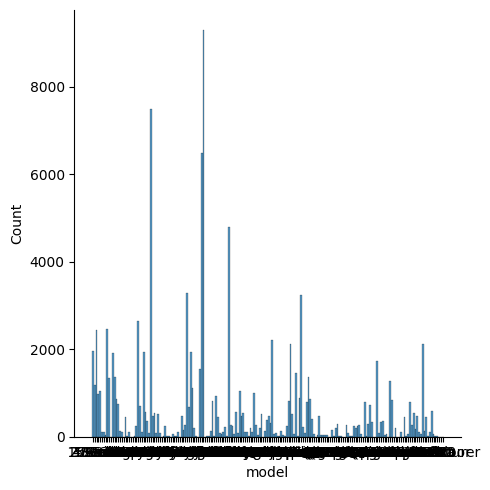

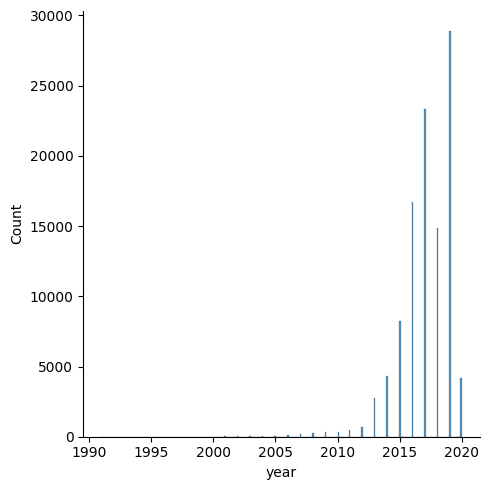

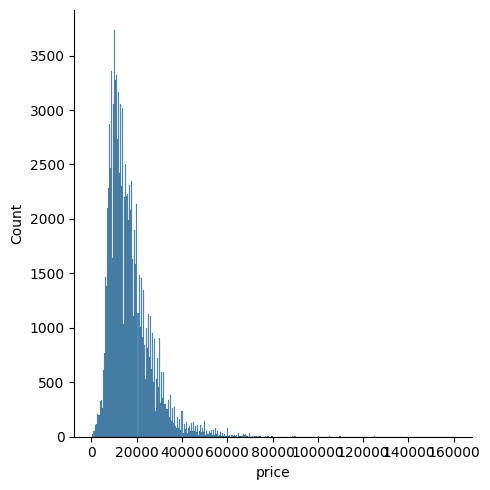

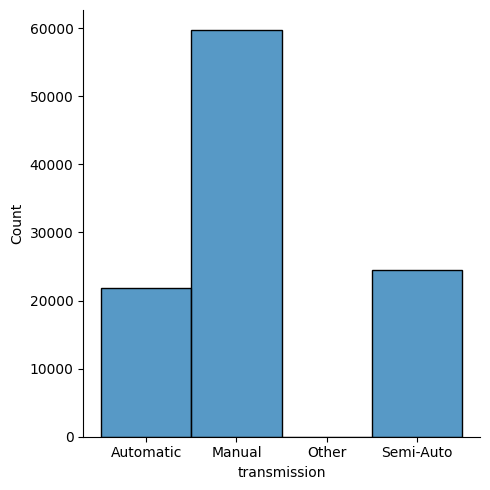

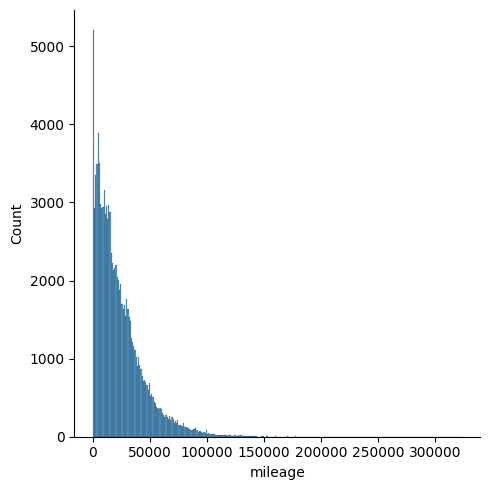

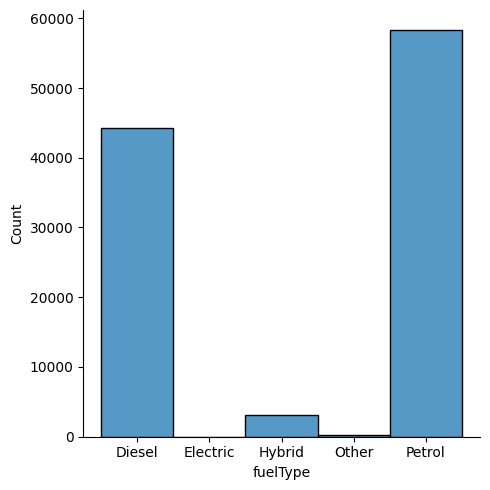

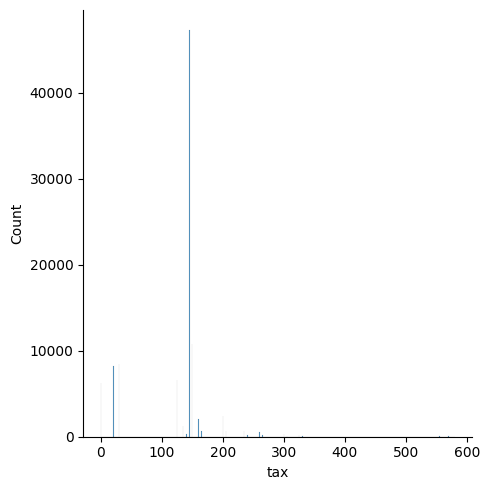

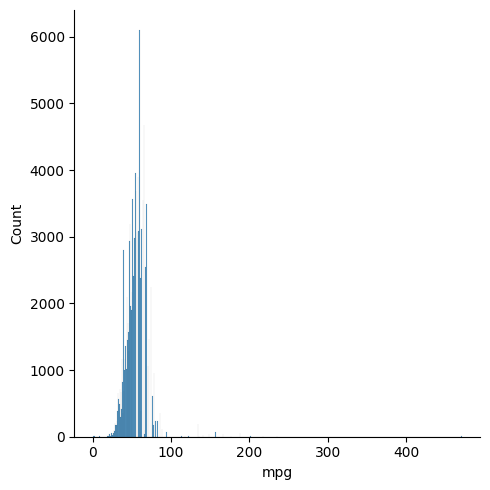

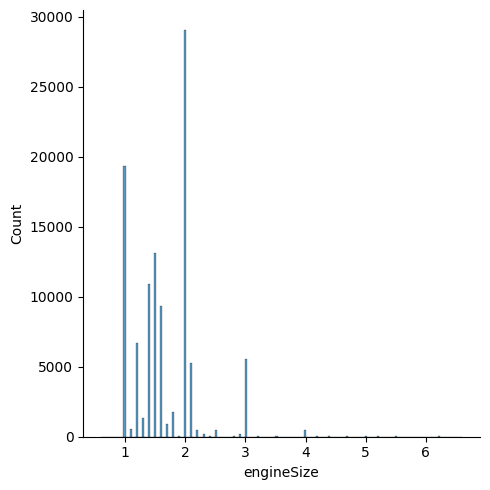

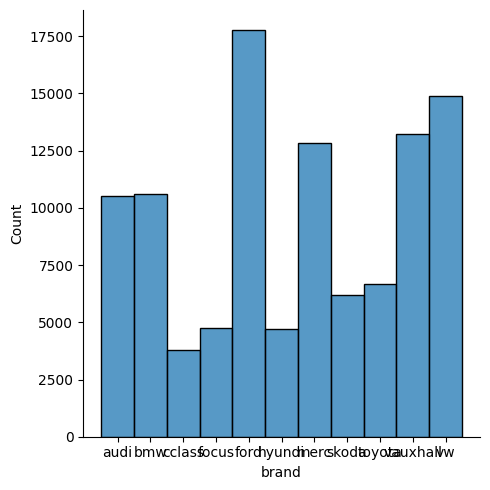

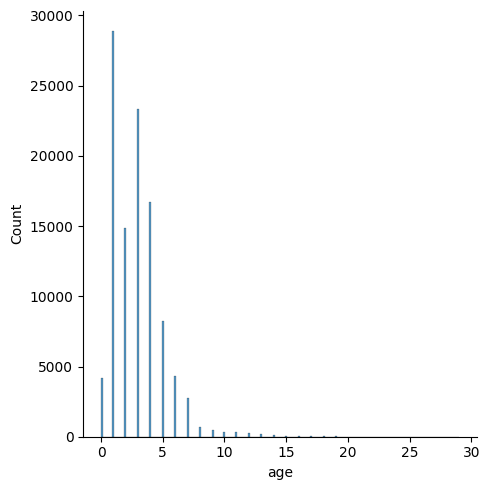

In [16]:
for n in df:
    sns.displot(x = df[n])
    plt.tight_layout()
    plt.show()

<Axes: xlabel='price', ylabel='Count'>

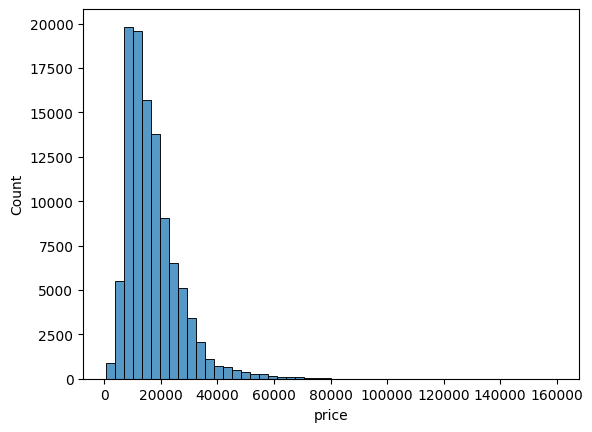

In [17]:
df['price'].describe()
sns.histplot(df['price'], bins=50)

<Axes: xlabel='age', ylabel='price'>

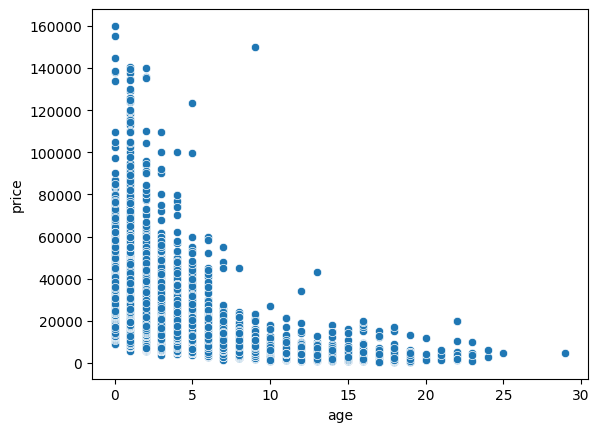

In [18]:
df["age"] = 2020 - df["year"]
sns.scatterplot(x="age", y="price", data=df)

<Axes: xlabel='mileage', ylabel='price'>

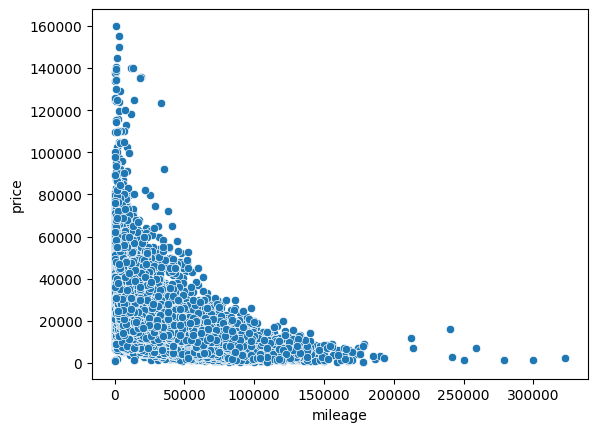

In [19]:
sns.scatterplot(x="mileage", y="price", data=df)

# Visual EDA (Exploratory Data Analysis)

## Model Popularity

The treemap visualization highlights the distribution of car models in the dataset.

- A small number of models dominate the market.
- Popular models such as *Focus*, *C Class*, *Fiesta*, and *3 Series* occupy a large share of listings.
- Long-tail distribution is present: many models appear with significantly lower frequency.

This indicates a highly skewed market structure where a few models generate the majority of listings.

---

## Year Distribution

- Most vehicles were manufactured between **2015 and 2019**.
- The dataset contains very few older vehicles.
- This reflects a secondary market concentrated around 4–8 year old cars.

The strong concentration in recent years may influence depreciation modelling.

---

## Price Distribution

- Price distribution is **right-skewed**.
- Majority of vehicles are priced between **£5,000 – £25,000**.
- Extreme high-value vehicles create a long tail.

This suggests that applying a **log transformation** is appropriate before regression modelling.

---

## Transmission Distribution

- Manual transmission dominates the dataset.
- Automatic vehicles form a significant secondary group.
- Semi-automatic and other types are rare.

This reflects typical UK market preferences.

---

## Mileage Distribution

- Mileage distribution is right-skewed.
- Most vehicles fall below **60,000 miles**.
- Long-tail behaviour exists for high-mileage vehicles.

Mileage is expected to show strong inverse relationship with price.

---

## Fuel Type Distribution

- Petrol vehicles dominate the market.
- Diesel vehicles form a substantial share.
- Hybrid and Electric vehicles represent a small fraction.

This may influence price modelling due to differences in efficiency and taxation.

---

## MPG Distribution

- Majority of vehicles cluster between **40–70 mpg**.
- Extreme values likely represent hybrid or electric entries.
- Potential outliers may require filtering.

---

## Engine Size Distribution

- Most engine sizes fall between **1.2L and 2.0L**.
- Larger engines (>3.0L) are relatively rare.
- Engine size is expected to positively correlate with price.

---

## Brand Distribution

- The dataset is dominated by several major brands.
- Some brands appear significantly more frequently than others.
- Brand-level segmentation may improve model performance.

---

## Age Distribution

- Majority of vehicles are between **1–6 years old**.
- Very old vehicles represent a small fraction.
- Depreciation modelling should focus on early-life value decline.

---

# Key Observations from Visual EDA

1. The dataset is strongly right-skewed in price and mileage.
2. Market concentration exists at both model and brand levels.
3. The secondary market is dominated by relatively recent vehicles.
4. Feature engineering (age, log_price) is justified.
5. The dataset is suitable for regression modelling and business valuation insights.

<Axes: xlabel='engineSize', ylabel='price'>

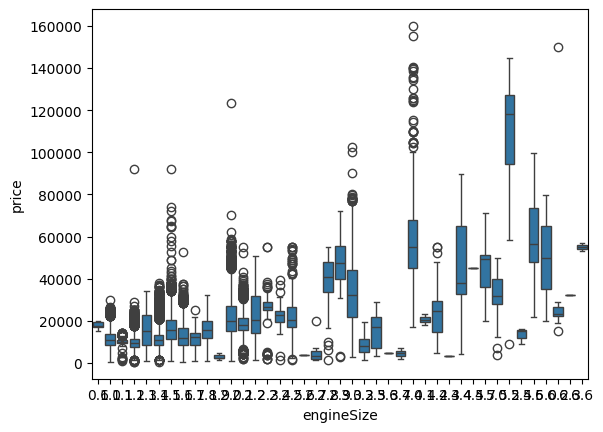

In [20]:
sns.boxplot(x="engineSize", y="price", data=df)

/tmp/ipykernel_55/3069760481.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



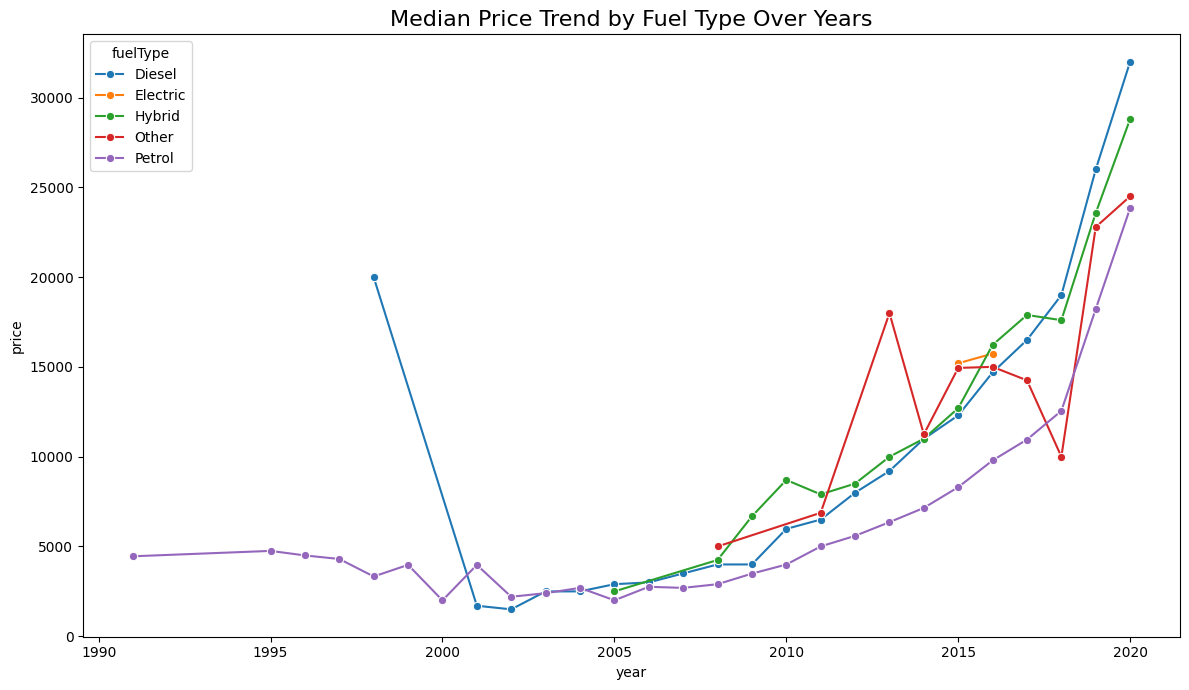

In [21]:
avg_price = df.groupby(["year","fuelType"])["price"].median().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=avg_price,
    x="year",
    y="price",
    hue="fuelType",
    marker="o"
)

plt.title("Median Price Trend by Fuel Type Over Years", fontsize=16)
plt.tight_layout()
plt.show()

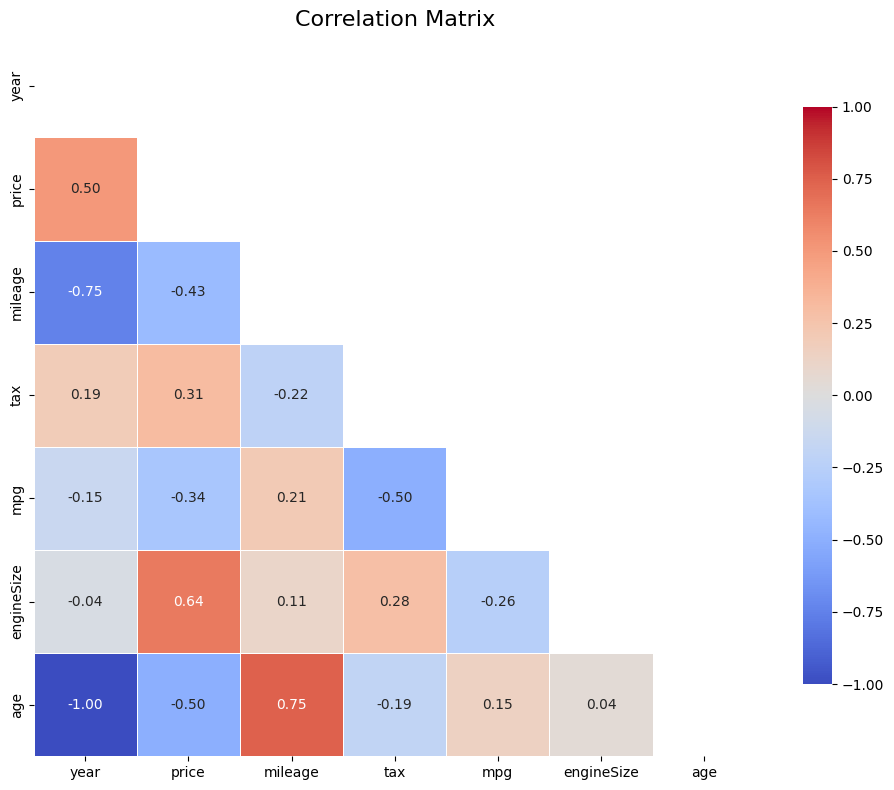

In [22]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,         
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8},
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

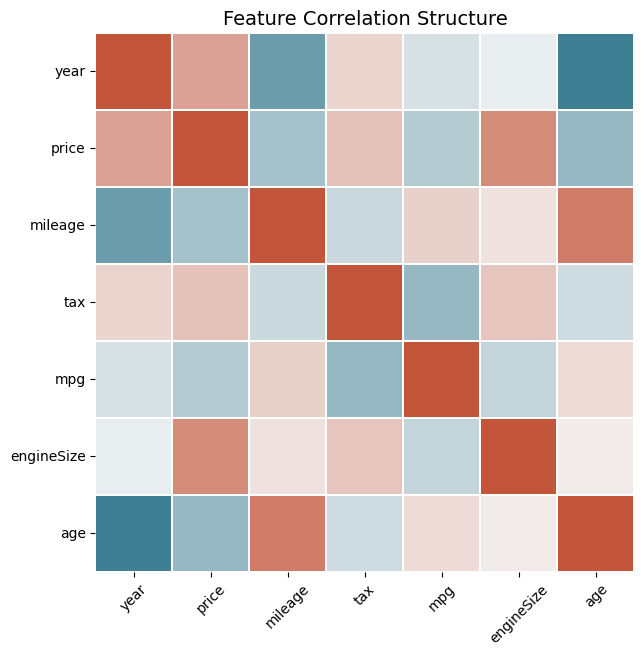

In [23]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    annot=False,
    linewidths=0.3,
    square=True,
    cbar=False
)

plt.title("Feature Correlation Structure", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

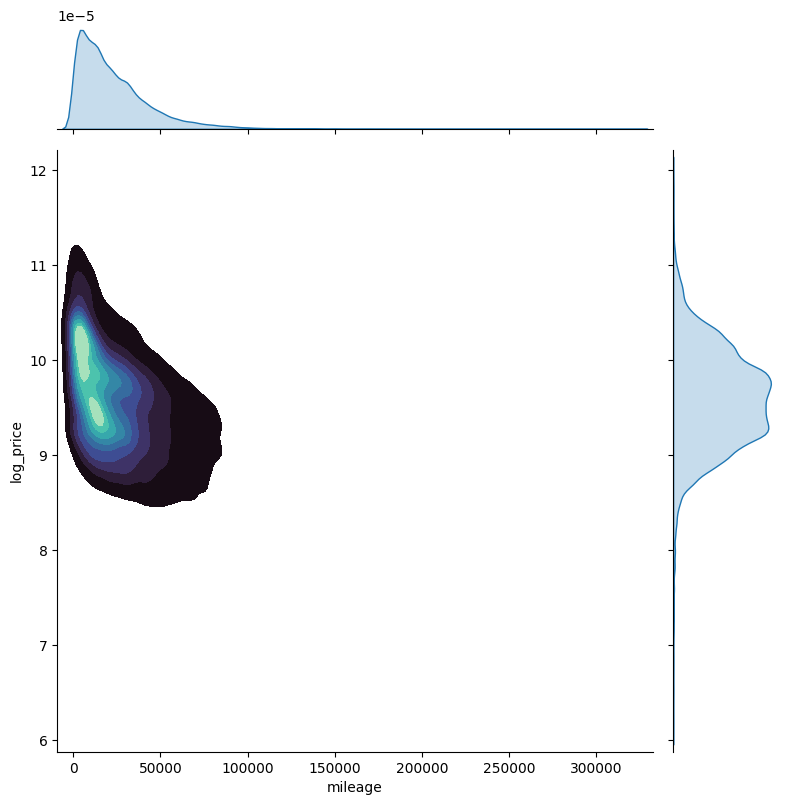

In [24]:
df["log_price"] = np.log1p(df["price"])

sns.jointplot(
    data=df,
    x="mileage",
    y="log_price",
    kind="kde",
    height=8,
    fill=True,
    cmap="mako"
)

plt.show()

# 📈 Price Dynamics & Feature Relationships

## ⛽ Median Price Trend by Fuel Type Over Years

The median price trend shows a clear upward movement for all fuel types in recent years.

### Key Observations:

- Diesel and Hybrid vehicles show strong price growth after 2014.
- Electric vehicles demonstrate rapid appreciation in the latest years.
- Petrol vehicles grow more steadily but remain slightly lower than Diesel in median price.
- Market acceleration after 2016 is clearly visible.

This suggests increasing demand for newer vehicles and technological transition in the automotive market.

---

# 🔗 Correlation Analysis

## 📊 Correlation Matrix Insights

The correlation matrix reveals several important structural relationships:

### Strong Relationships

- **Age vs Year: -1.00**  
  (Expected perfect inverse relationship)

- **Mileage vs Age: +0.74**  
  Older cars tend to have higher mileage.

- **Engine Size vs Price: +0.63**  
  Larger engines are generally associated with higher prices.

- **Year vs Price: +0.50**  
  Newer vehicles tend to be more expensive.

### Negative Relationships

- **Mileage vs Price: -0.43**  
  Higher mileage reduces vehicle value.

- **MPG vs Engine Size: -0.25**  
  Larger engines tend to have lower fuel efficiency.

---

## 🎯 Structural Interpretation

The dataset follows expected automotive market mechanics:

- Vehicle depreciation driven by age and mileage.
- Engine size acts as a premium feature.
- Tax and MPG provide moderate explanatory power.
- Strong multicollinearity between age and year (one should be removed in modelling).

---

# 📉 Log Price Transformation

The original price distribution was highly right-skewed.

After applying:

```python
df["log_price"] = np.log1p(df["price"])

In [26]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'brand', 'age', 'log_price'],
      dtype='object')

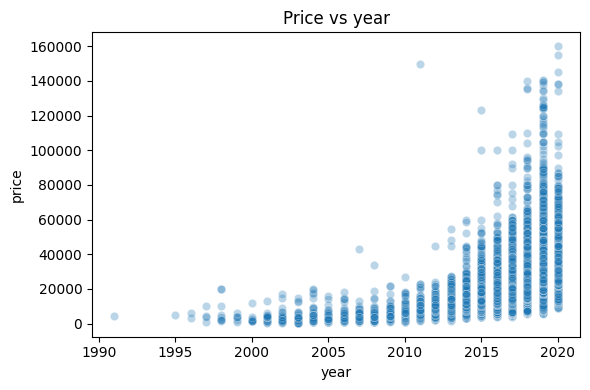

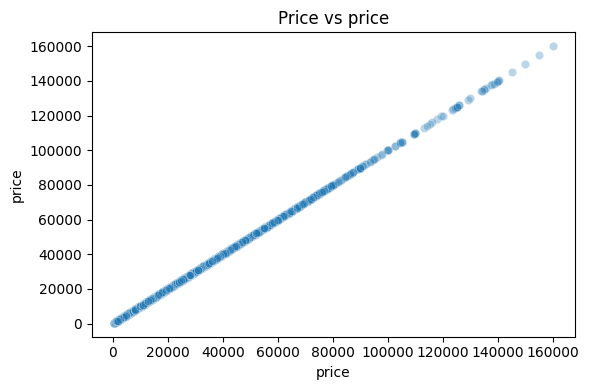

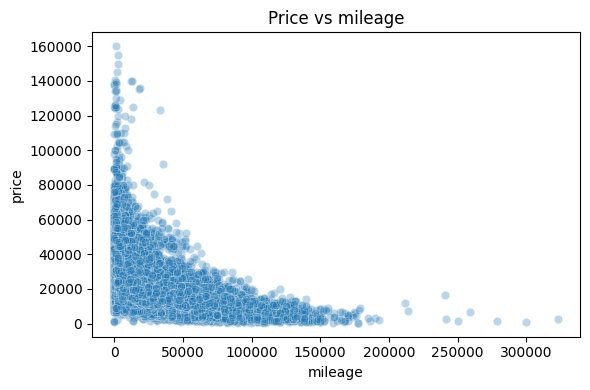

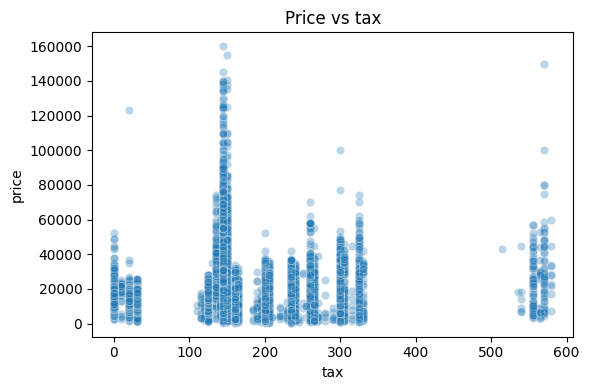

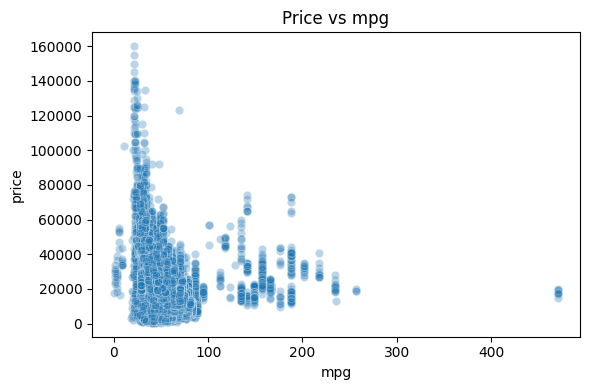

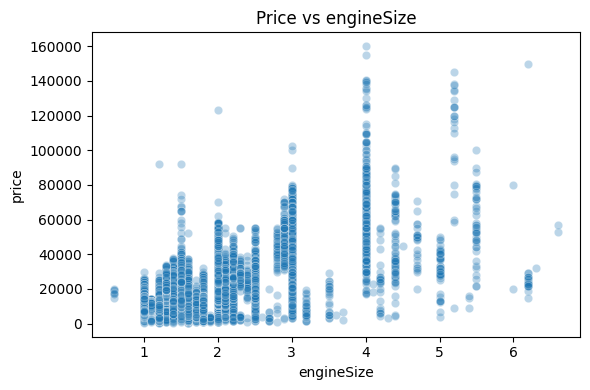

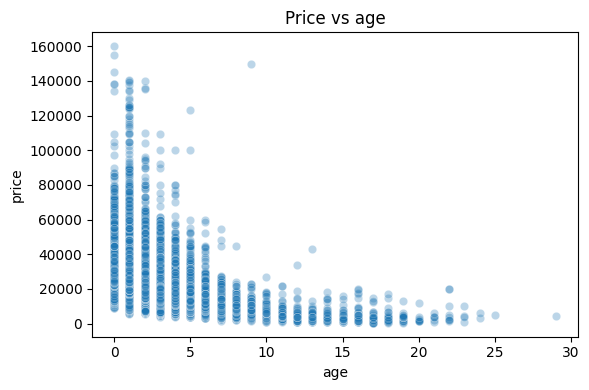

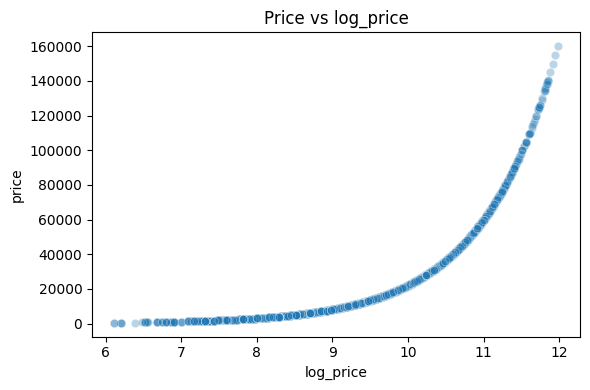

In [42]:
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["price"], alpha=0.3)
    plt.title(f"Price vs {col}")
    plt.tight_layout()
    plt.show()

# Price vs Feature Analysis

## Price vs Year

- Clear positive relationship between manufacturing year and price.
- Newer vehicles command significantly higher prices.
- Price dispersion increases in recent years due to premium models.

Conclusion: Year is a strong driver of vehicle valuation.

---

## Price vs Price (Sanity Check)

- Perfect linear relationship (identity line).
- Confirms data consistency.

---

## Price vs Mileage

- Strong negative relationship.
- Price drops sharply within the first 60,000 miles.
- High-mileage vehicles (>150k miles) show significantly lower prices.

Conclusion: Mileage is one of the strongest depreciation factors.

---

## Price vs Tax

- Weak to moderate positive relationship.
- Tax values appear clustered at specific bands (policy-based grouping).
- High-tax vehicles tend to correspond to higher engine sizes.

Conclusion: Tax indirectly reflects engine and emissions category.

---

## Price vs MPG

- Mild negative relationship.
- Higher efficiency vehicles (high MPG) generally have lower engine sizes.
- Extreme MPG values likely represent hybrid/electric entries.

Conclusion: MPG influences price indirectly through engine size and fuel type.

---

## Price vs Engine Size

- Clear positive trend.
- Vehicles above 3.0L show significantly higher price variance.
- Larger engines associated with premium vehicle segments.

Conclusion: Engine size acts as a strong value amplifier.

---

## Price vs Age

- Strong inverse relationship.
- Sharp depreciation within first 5–8 years.
- Price stabilizes after 15+ years.

Conclusion: Age-driven depreciation follows expected market behaviour.

---

## Price vs Log(Price)

- Non-linear exponential relationship (as expected).
- Log transformation normalizes variance.
- Improves regression suitability.

Conclusion: Using `log_price` is statistically justified.

---

# Overall Structural Insights

1. Age and mileage are primary depreciation drivers.
2. Engine size increases price non-linearly.
3. Year strongly correlates with price due to recency premium.
4. Log transformation stabilizes variance.
5. Dataset exhibits realistic automotive market mechanics.

This structure supports robust regression modelling and explainability analysis.

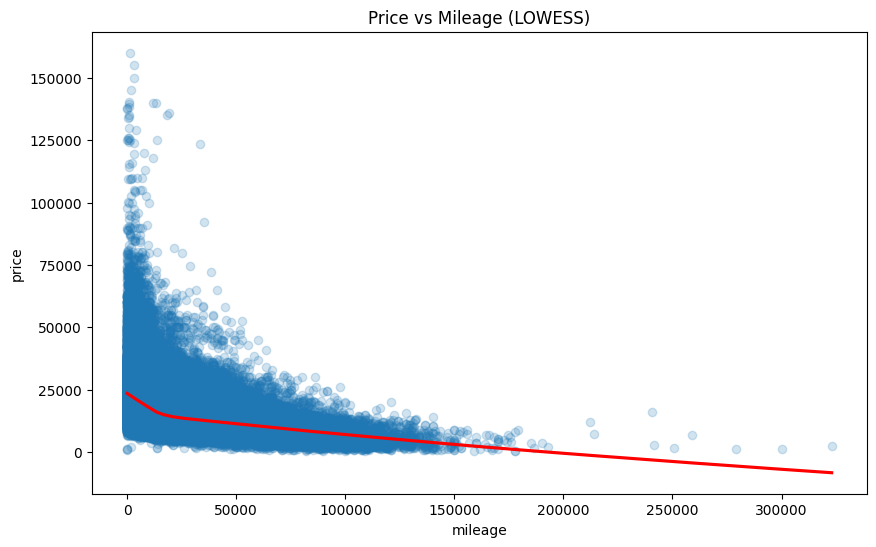

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="mileage",
    y="price",
    lowess=True,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Price vs Mileage (LOWESS)")
plt.show()

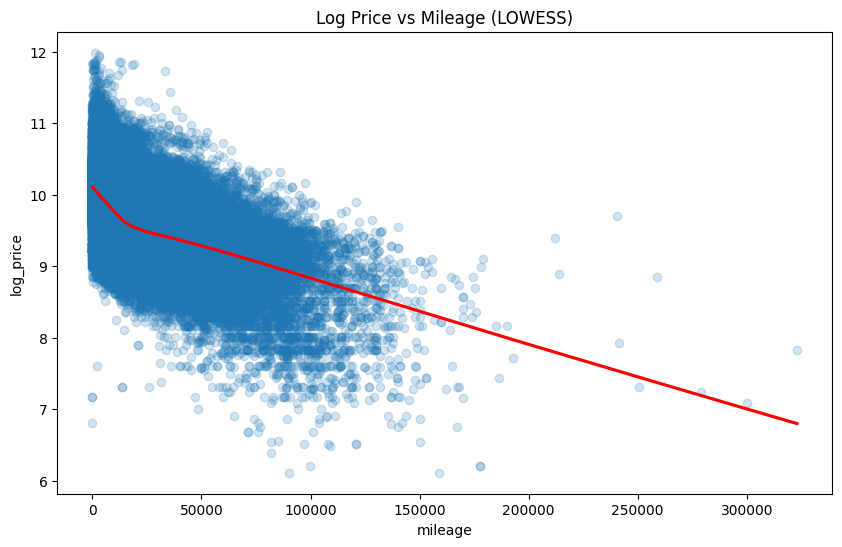

In [44]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="mileage",
    y="log_price",
    lowess=True,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Log Price vs Mileage (LOWESS)")
plt.show()

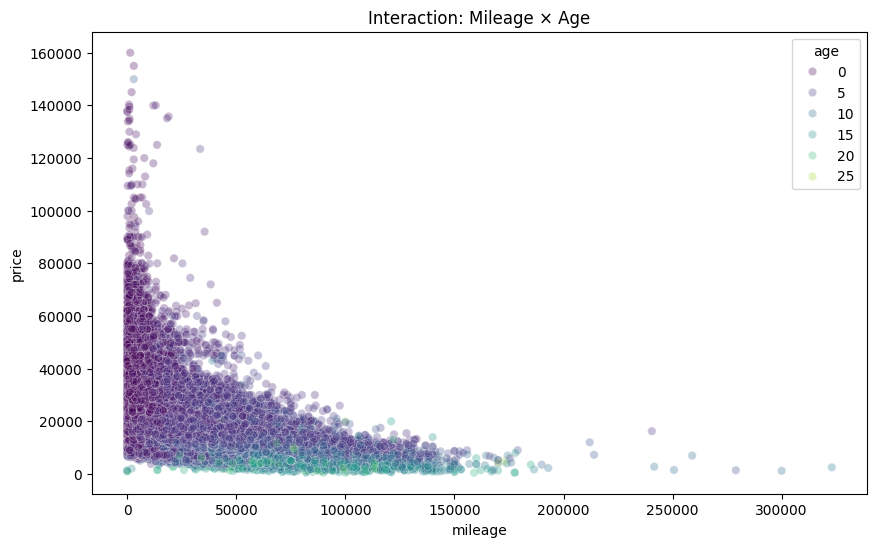

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="mileage",
    y="price",
    hue="age",
    palette="viridis",
    alpha=0.3
)

plt.title("Interaction: Mileage × Age")
plt.show()

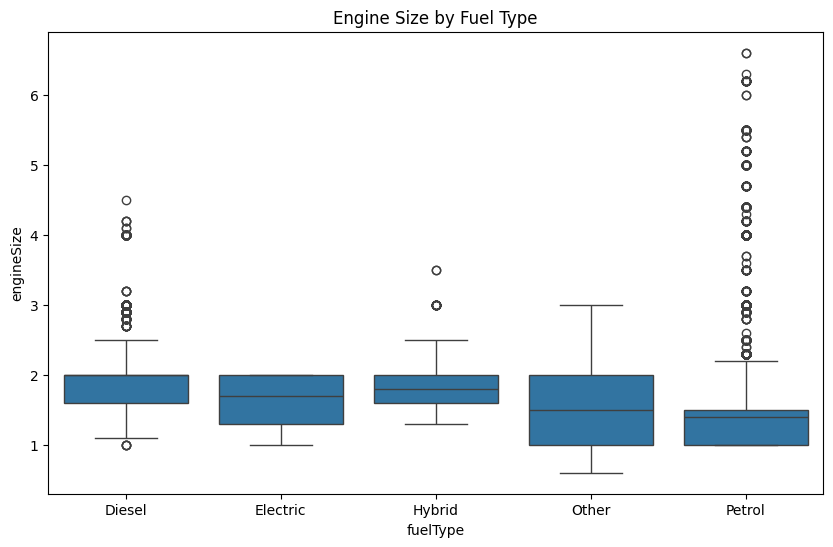

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fuelType",
    y="engineSize"
)

plt.title("Engine Size by Fuel Type")
plt.show()

/tmp/ipykernel_55/3926183634.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



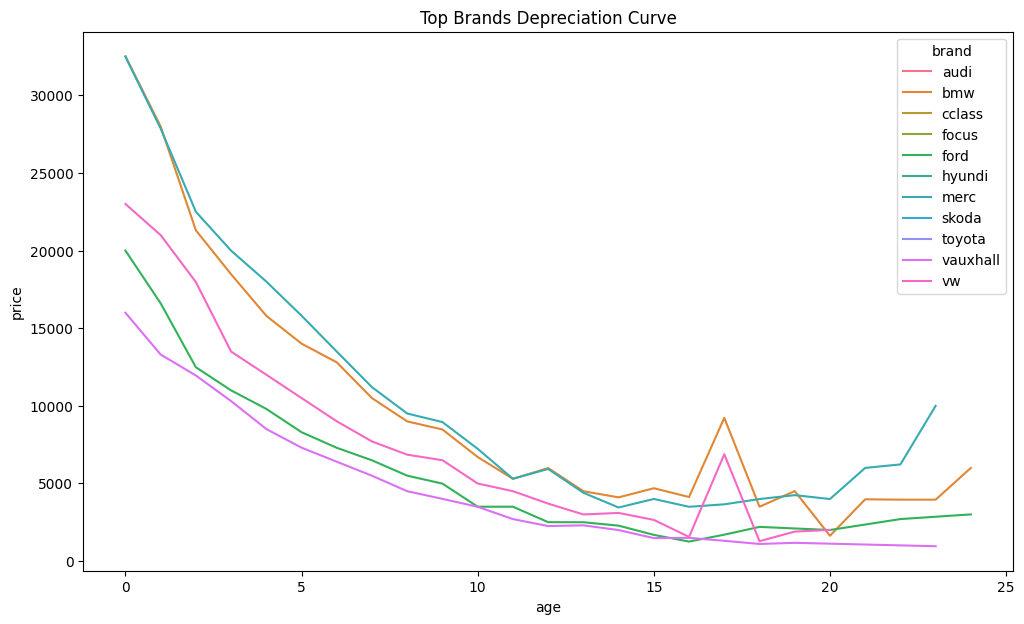

In [47]:
top_brands = df["brand"].value_counts().head(5).index
df_top = df[df["brand"].isin(top_brands)]

brand_age = df_top.groupby(["brand","age"])["price"].median().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=brand_age,
    x="age",
    y="price",
    hue="brand"
)

plt.title("Top Brands Depreciation Curve")
plt.show()

/tmp/ipykernel_55/4273442570.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



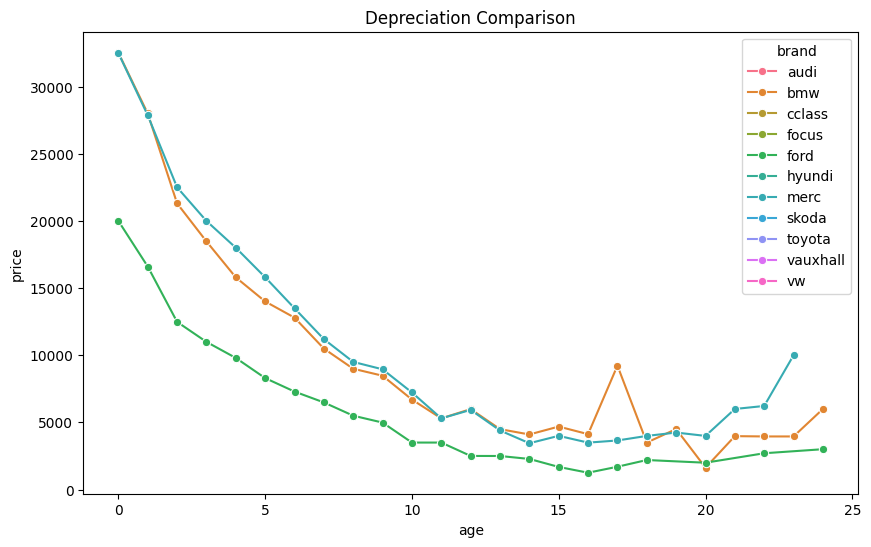

In [48]:
selected_brands = ["bmw","ford","merc"]
df_sel = df[df["brand"].isin(selected_brands)]

dep = df_sel.groupby(["brand","age"])["price"].median().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=dep,
    x="age",
    y="price",
    hue="brand",
    marker="o"
)

plt.title("Depreciation Comparison")
plt.show()

# 📊 Advanced EDA: Non-Linearity, Interactions & Depreciation Analysis

## 🚗 Brand Depreciation Comparison

The depreciation curves reveal clear differences in how vehicle value declines across brands.

### Key Observations:

- All brands experience the steepest depreciation within the first **3–5 years**.
- Premium brands (e.g., BMW, Mercedes) start at higher price levels but decline rapidly.
- Mass-market brands (e.g., Ford) show smoother and more gradual depreciation.
- After approximately **10–15 years**, price decline stabilizes.

### Interpretation:

Depreciation follows a non-linear decay pattern:
- Early-life depreciation is aggressive.
- Mid-life depreciation slows.
- Late-life vehicles approach a value floor.

This reflects realistic automotive market mechanics.

---

## 🔧 Engine Size by Fuel Type

The distribution of engine size varies significantly across fuel types.

### Observations:

- Petrol vehicles show the widest engine size distribution.
- Hybrid vehicles cluster in mid-range engine sizes.
- Diesel engines remain relatively concentrated.
- Extreme engine sizes (>6L) represent premium or performance segments.

### Interpretation:

Engine size contributes to price variance and interacts with fuel type segmentation.

---

## 🔄 Interaction: Mileage × Age

The interaction analysis shows:

- Older vehicles generally have higher mileage.
- Younger vehicles with unusually high mileage experience sharper price reductions.
- A triangular structure emerges, indicating economic constraints:
  - High price is only sustainable at low mileage and low age.

### Interpretation:

Mileage and age jointly drive depreciation.  
Their interaction effect strengthens predictive modelling.

---

## 📉 Non-Linearity: Log Price vs Mileage (LOWESS)

The LOWESS curve confirms a non-linear relationship:

- Sharp price decline at low mileage.
- Gradual stabilization as mileage increases.
- Clear downward trend after transformation.

### Why This Matters:

- Linear regression on raw price would underperform.
- Log transformation stabilizes variance.
- Non-linear modelling techniques (e.g., tree-based models) are justified.

---

# 🎯 Structural Market Insights

1. Depreciation is strongest in early vehicle life-cycle.
2. Age and mileage jointly determine price trajectory.
3. Premium brands exhibit higher volatility.
4. Engine size amplifies valuation.
5. Log transformation improves modelling stability.

The dataset demonstrates economically interpretable behaviour, supporting advanced regression modelling and explainability analysis.

In [50]:
# numeric conversion
for c in ["year", "mileage", "engineSize", "tax", "mpg", "price"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# Basic Features
if "year" in df.columns:
    df["vehicle_age"] = 2025 - df["year"]
    df["CAE"] = np.log1p(df["vehicle_age"].clip(lower=0))

if "mileage" in df.columns:
    df["log_mileage"] = np.log1p(df["mileage"].clip(lower=0))

if "mileage" in df.columns and "vehicle_age" in df.columns:
    df["km_per_year"] = df["mileage"] / (df["vehicle_age"] + 1)

if "log_mileage" in df.columns and "CAE" in df.columns:
    df["mileage_age_interaction"] = df["log_mileage"] * df["CAE"]


# binary features
if "mileage" in df.columns:
    df["high_mileage"] = (df["mileage"] > 100_000).astype(int)

if "engineSize" in df.columns:
    df["large_engine"] = (df["engineSize"] >= 2.0).astype(int)

if "transmission" in df.columns and "engineSize" in df.columns:
    df["auto_large_engine"] = (
        (df["transmission"].astype(str) == "Automatic") & 
        (df["engineSize"] >= 2.0)
    ).astype(int)


# target
if "price" in df.columns:
    df["log_price"] = np.log1p(df["price"])

In [51]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,log_price,vehicle_age,CAE,log_mileage,km_per_year,mileage_age_interaction,high_mileage,large_engine,auto_large_engine
0,C Class,2020,30495.0,Automatic,1200,Diesel,NaN,NaN,2.0,cclass,0,10.325351,5,1.791759,7.090910,200.000000,12.705205,0,1,1
1,C Class,2020,29989.0,Automatic,1000,Petrol,NaN,NaN,1.5,cclass,0,10.308619,5,1.791759,6.908755,166.666667,12.378827,0,0,0
2,C Class,2020,37899.0,Automatic,500,Diesel,NaN,NaN,2.0,cclass,0,10.542706,5,1.791759,6.216606,83.333333,11.138663,0,1,1
3,C Class,2019,30399.0,Automatic,5000,Diesel,NaN,NaN,2.0,cclass,1,10.322198,6,1.945910,8.517393,714.285714,16.574082,0,1,1
4,C Class,2019,29899.0,Automatic,4500,Diesel,NaN,NaN,2.0,cclass,1,10.305614,6,1.945910,8.412055,642.857143,16.369103,0,1,1


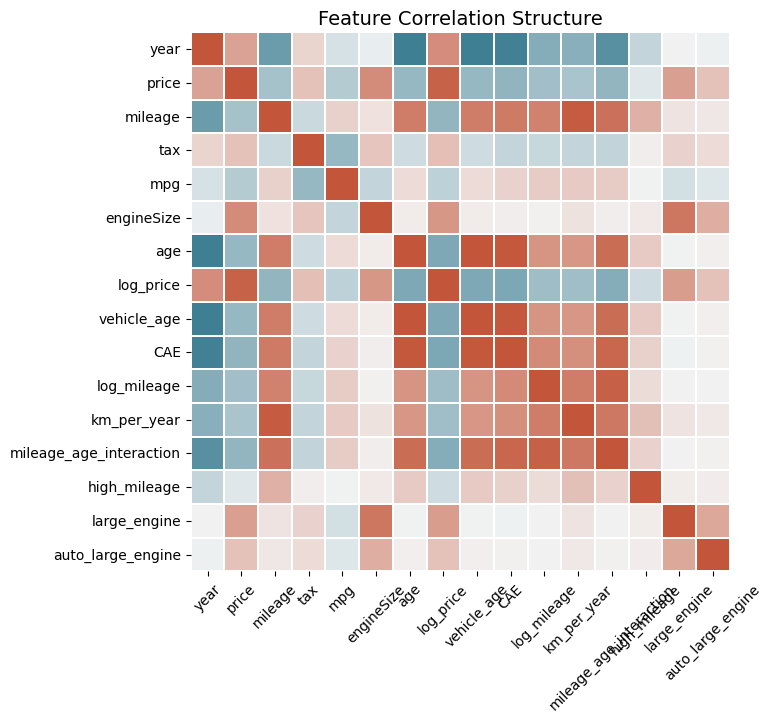

In [55]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    annot=False,
    linewidths=0.3,
    square=True,
    cbar=False
)

plt.title("Feature Correlation Structure", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


### `vehicle_age`
**Definition:**  
`current_year − year`

**Description:**  
Represents the age of the vehicle in years. Vehicle age is one of the strongest predictors of used-car price due to depreciation over time.

---

### `CAE` (Compressed Age Effect)
**Definition:**  
`log(1 + vehicle_age)`

**Description:**  
Log-scaled vehicle age that compresses the effect of very old vehicles. This stabilizes the relationship between age and price and improves linear model performance.

---

### `log_mileage`
**Definition:**  
`log(1 + mileage)`

**Description:**  
Log-transformed mileage to handle the heavy-tailed distribution of vehicle usage. Reduces the influence of extreme mileage values.

---

### `km_per_year`
**Definition:**  
`mileage / (vehicle_age + 1)`

**Description:**  
Average mileage per year. Distinguishes between high mileage caused by age and intensive vehicle usage, capturing wear intensity more accurately.

---

### `mileage_age_interaction`
**Definition:**  
`log_mileage × CAE`

**Description:**  
Interaction feature capturing the joint effect of age and mileage. Encodes non-linear depreciation patterns that linear models cannot capture directly.

---

## Binary Market Indicators

### `high_mileage`
**Definition:**  
`1 if mileage > 100,000 else 0`

**Description:**  
Flags vehicles exceeding a psychologically important mileage threshold commonly used in the used-car market.

---

### `large_engine`
**Definition:**  
`1 if engineSize ≥ 2.0 else 0`

**Description:**  
Identifies vehicles with larger engines, typically associated with higher taxes, insurance costs, and different buyer segments.

---

### `auto_large_engine`
**Definition:**  
`1 if transmission == "Automatic" and engineSize ≥ 2.0 else 0`

**Description:**  
Captures premium vehicle configurations combining automatic transmission and large engines, often linked to higher market prices.

---

## Target Transformation

### `log_price`
**Definition:**  
`log(1 + price)`

**Description:**  
Log-transformed target variable. Reduces heteroscedasticity and improves regression stability by making price errors more symmetric.
